# Moran's Index for hypsometric

In [ ]:
import pip
pip.main(['install','matplotlib-scalebar'])

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sbn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx
import pysal
from pysal.explore import esda
from pysal.viz import splot
from pysal.lib import weights
from splot.esda import lisa_cluster
from splot.esda import plot_moran
from splot.esda import plot_local_autocorrelation, moran_scatterplot

import warnings
warnings.filterwarnings("ignore")

C:\Users\edier\miniconda3\Lib\site-packages\spaghetti\network.py:40: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


### Catchments

In [59]:
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/df_catchments_kmeans.gpkg")
cat.head(2)

,ID_CUENCA,Nombre,kmeans,NOMZH,Área,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,Densidad,hypso_inte,slope_mean,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,kmeans4,geometry
0,1.0,Quebrada Sabalito,A,Magdalena,33.492364,58.212878,57.070824,25.697303,26.0,3457.470653,0.0,0.334,4.334927,2611.998779,2581.0,grass,sediment,0.0,B,"POLYGON ((505464.576 881616.272, 505673.255 88..."
1,4.0,Caño del Jobo,A,Magdalena,22.896987,58.684427,57.120480,25.061783,24.0,3380.155026,0.0,0.270,4.466684,2548.357110,2563.0,grass,sediment,0.0,B,"POLYGON ((504291.456 879208.833, 504395.386 87..."


In [5]:
w_dist20km = weights.DistanceBand.from_dataframe(cat, 20000, binary=False)

In [60]:
knn = weights.KNN.from_dataframe(cat, k=4)

In [61]:
cat['w_hypso'] = weights.lag_spatial(knn, cat['hypso_inte'])
cat['slope_mean'] = weights.lag_spatial(knn, cat['slope_mean'])
cat['rel_mean'] = weights.lag_spatial(knn, cat['rel_mean'])
cat['elev_mean'] = weights.lag_spatial(knn, cat['elev_mean'])

### Landslide density

In [28]:
cat["landslide_dens"]=cat["lands_rec"]/cat["Área"]

In [29]:
cat["landslide_dens"] = weights.lag_spatial(knn, cat["landslide_dens"])
mi = esda.Moran(cat["landslide_dens"], knn)
lisa = esda.Moran_Local(cat["landslide_dens"], knn)

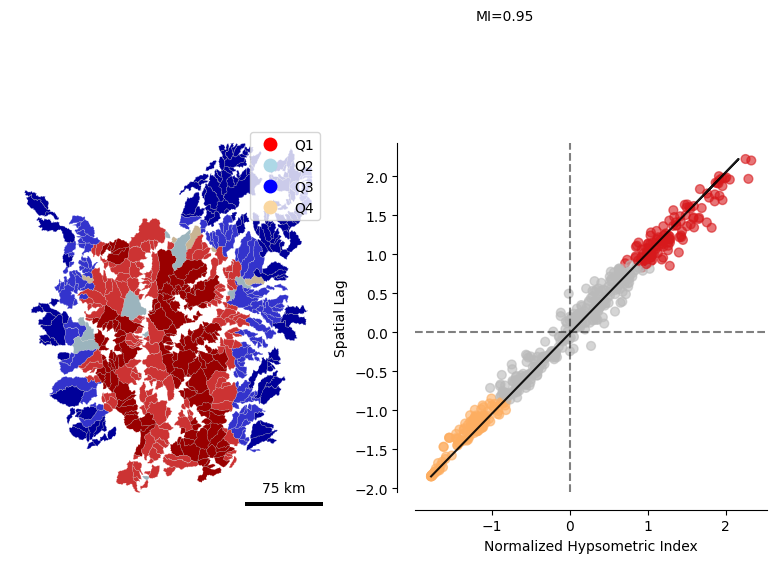

In [76]:
f, ax = plt.subplots(nrows=1, ncols=2,figsize=(10,5))
axs = ax.flatten()

q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
cat.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', legend=True)

sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant'] 
labels2 = [labels2[i] for i in sig]
cat.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', alpha=0.40)
ax[0].set_aspect('equal')
scalebar = ScaleBar(1,"m",location="lower right",scale_loc="top",length_fraction=0.25)
ax[0].add_artist(scalebar)
ax[0].set_axis_off()

moran_scatterplot(lisa, p=0.05,ax=ax[1])
ax[1].text(-1.2,4,f'MI={round(mi.I, 2)}')
ax[1].set_xlabel("Normalized Hypsometric Index")
ax[1].set_title('');
                            
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras2/landslides_dens_moran.png", dpi=500);

### Hypsometric integral

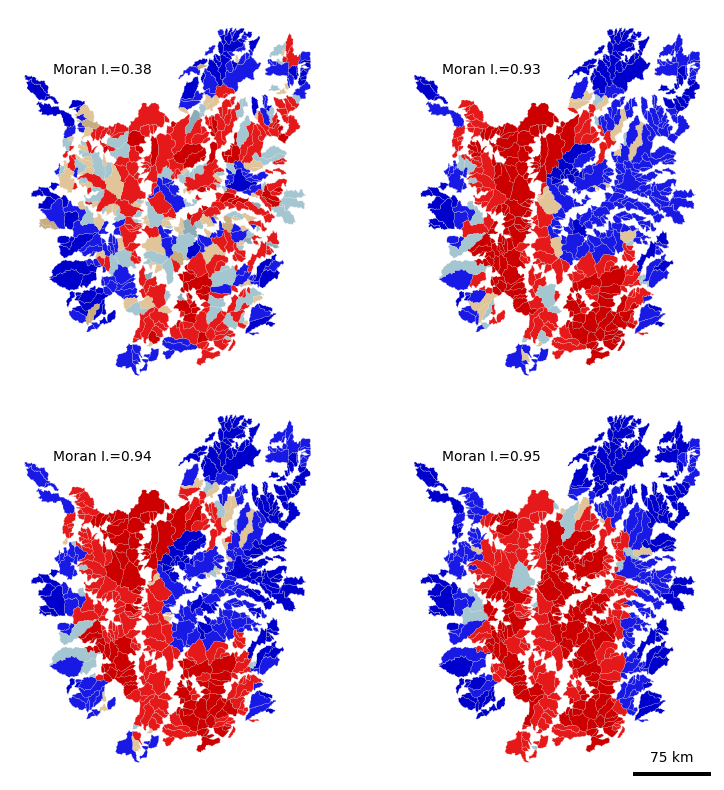

In [75]:
from matplotlib.colors import ListedColormap
f, ax = plt.subplots(nrows=2, ncols=2,figsize=(10,10))
axs = ax.flatten()

mi = esda.Moran(cat['hypso_inte'], knn)
lisa = esda.Moran_Local(cat['hypso_inte'], knn)
ax = axs[0]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
cat.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white',
                            legend=True)
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant'] 
labels2 = [labels2[i] for i in sig]
cat.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', alpha=0.20)
ax.text(320000,840000,f'Moran I.={round(mi.I, 2)}')
ax.legend(['Q1', 'Q2', 'Q3', 'Q4'],loc="lower right",frameon=False)
ax.set_aspect('equal')
ax.set_axis_off()

mi = esda.Moran(cat['slope_mean'], knn)
lisa = esda.Moran_Local(cat['slope_mean'], knn)
ax = axs[1]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
cat.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white')
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant'] 
labels2 = [labels2[i] for i in sig]
cat.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', alpha=0.20)
ax.text(320000,840000,f'Moran I.={round(mi.I, 2)}')
ax.set_aspect('equal')
ax.set_axis_off()

mi = esda.Moran(cat['rel_mean'], knn)
lisa = esda.Moran_Local(cat['rel_mean'], knn)
ax = axs[2]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
cat.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white')
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant'] 
labels2 = [labels2[i] for i in sig]
cat.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', alpha=0.20)
ax.text(320000,840000,f'Moran I.={round(mi.I, 2)}')
ax.set_aspect('equal')
ax.set_axis_off()

mi = esda.Moran(cat['elev_mean'], knn)
lisa = esda.Moran_Local(cat['elev_mean'], knn)
ax = axs[3]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
cat.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white')
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant'] 
labels2 = [labels2[i] for i in sig]
cat.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', alpha=0.20)
ax.text(320000,840000,f'Moran I.={round(mi.I, 2)}')
ax.set_aspect('equal')
ax.set_axis_off()
scalebar = ScaleBar(1,"m",location="lower right",scale_loc="top",length_fraction=0.25)
ax.add_artist(scalebar)

f.subplots_adjust(wspace=0.01, hspace=0.01);
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras2/all_moran.png", dpi=500);